# 04 - Analise exploratoria dos dados interim

Esta segunda analise olha para os dados em `data/interim`, antes do preprocessamento usado para modelagem. O objetivo e entender a base como ela chega ao projeto: qualidade, descricoes de produtos, NCM, relacao entre descricao e NCM, e contexto da compra.

A analise separa as linhas de item usando a presenca da coluna de descricao do produto/servico. Isso e importante porque os arquivos interim tambem podem conter linhas com metadados da nota fiscal, nas quais as colunas de item ficam vazias.

In [31]:
from pathlib import Path
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

DATASET_NAME = os.getenv("DATASET_NAME", "items-notas-fiscais")

# Sobresecreve analise
DATASET_NAME = "items-notas-fiscais-ncm-prefixos"

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
ITEMS_DIR = INTERIM_DIR / DATASET_NAME

UNIQUE_ITEMS_PATH = INTERIM_DIR / "items-unicos" / DATASET_NAME / "produtos-unicos.csv"
LEGACY_UNIQUE_ITEMS_PATH = INTERIM_DIR / "items-unicos" / "produtos-unicos-202501-202504.csv"
if DATASET_NAME == "items-notas-fiscais" and not UNIQUE_ITEMS_PATH.exists():
    UNIQUE_ITEMS_PATH = LEGACY_UNIQUE_ITEMS_PATH

parquet_paths = sorted(ITEMS_DIR.glob("*.parquet"))
{
    "DATASET_NAME": DATASET_NAME,
    "ITEMS_DIR": ITEMS_DIR,
    "UNIQUE_ITEMS_PATH": UNIQUE_ITEMS_PATH,
    "parquet_files": parquet_paths,
}

{'DATASET_NAME': 'items-notas-fiscais-ncm-prefixos',
 'ITEMS_DIR': WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais-ncm-prefixos'),
 'UNIQUE_ITEMS_PATH': WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-unicos/items-notas-fiscais-ncm-prefixos/produtos-unicos.csv'),
 'parquet_files': [WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais-ncm-prefixos/2025-01.parquet'),
  WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais-ncm-prefixos/2025-02.parquet'),
  WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais-ncm-prefixos/2025-03.parquet'),
  WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais-ncm-prefixos/2025-04.parquet')]}

In [32]:
def find_col(columns, *patterns):
    """Return the first column whose uppercase name contains all informed patterns."""
    normalized = {col: str(col).upper() for col in columns}
    for col, upper in normalized.items():
        if all(pattern.upper() in upper for pattern in patterns):
            return col
    raise KeyError(f"Nenhuma coluna encontrada para os padroes: {patterns}")


def optional_col(columns, *patterns):
    """Return a matching column or None when the source file does not provide it."""
    try:
        return find_col(columns, *patterns)
    except KeyError:
        return None


def to_number_br(series):
    """Convert Brazilian numeric strings such as '1.234,56' to float."""
    return pd.to_numeric(
        series.astype("string")
        .str.strip()
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce",
    )


def pct(series):
    """Format a ratio as percentage."""
    return (100 * series).round(2)

## Carregamento

Os arquivos mensais em Parquet sao combinados em um unico `DataFrame`. A coluna `mes_arquivo` e derivada do nome do arquivo para permitir comparacoes temporais simples.

In [33]:
if not parquet_paths:
    raise FileNotFoundError(f"Nenhum Parquet encontrado em {ITEMS_DIR}")

frames = []
for path in parquet_paths:
    month_df = pd.read_parquet(path)
    month_df["mes_arquivo"] = path.stem
    frames.append(month_df)

df = pd.concat(frames, ignore_index=True)
df.shape

(483001, 40)

In [34]:
desc_col = find_col(df.columns, "PRODUTO/SERV")
ncm_col = find_col([col for col in df.columns if "TIPO" not in str(col).upper()], "NCM/SH")
ncm_tipo_col = optional_col(df.columns, "NCM/SH", "TIPO")
emitente_col = optional_col(df.columns, "SOCIAL", "EMITENTE")
cnpj_emitente_col = optional_col(df.columns, "CPF/CNPJ", "EMITENTE")
uf_col = optional_col(df.columns, "UF", "EMITENTE")
municipio_col = optional_col(df.columns, "MUNIC", "EMITENTE")
unidade_col = optional_col(df.columns, "UNIDADE")
quantidade_col = optional_col(df.columns, "QUANTIDADE")
valor_unitario_col = optional_col(df.columns, "VALOR", "UNIT")
valor_total_col = optional_col(df.columns, "VALOR", "TOTAL")
valor_nota_col = optional_col(df.columns, "VALOR", "NOTA")
chave_col = optional_col(df.columns, "CHAVE")

cols = {
    "descricao": desc_col,
    "ncm": ncm_col,
    "ncm_tipo": ncm_tipo_col,
    "emitente": emitente_col,
    "cnpj_emitente": cnpj_emitente_col,
    "uf_emitente": uf_col,
    "municipio_emitente": municipio_col,
    "unidade": unidade_col,
    "quantidade": quantidade_col,
    "valor_unitario": valor_unitario_col,
    "valor_total": valor_total_col,
    "valor_nota": valor_nota_col,
    "chave_acesso": chave_col,
}
pd.Series(cols, name="coluna_detectada")

descricao             DESCRIÇÃO DO PRODUTO/SERVIÇO
ncm                                  CÓDIGO NCM/SH
ncm_tipo                  NCM/SH (TIPO DE PRODUTO)
emitente                     RAZÃO SOCIAL EMITENTE
cnpj_emitente                    CPF/CNPJ Emitente
uf_emitente                            UF EMITENTE
municipio_emitente              MUNICÍPIO EMITENTE
unidade                                    UNIDADE
quantidade                              QUANTIDADE
valor_unitario                      VALOR UNITÁRIO
valor_total                            VALOR TOTAL
valor_nota                       VALOR NOTA FISCAL
chave_acesso                       CHAVE DE ACESSO
Name: coluna_detectada, dtype: str

In [35]:
items = df[df[desc_col].notna()].copy()
items["descricao_limpa_minima"] = items[desc_col].astype("string").str.strip().str.lower()
items["ncm_str"] = items[ncm_col].astype("string").str.replace(r"\.0$", "", regex=True).str.zfill(8)
items.loc[items[ncm_col].isna(), "ncm_str"] = pd.NA

if quantidade_col:
    items["quantidade_num"] = to_number_br(items[quantidade_col])
if valor_unitario_col:
    items["valor_unitario_num"] = to_number_br(items[valor_unitario_col])
if valor_total_col:
    items["valor_total_num"] = to_number_br(items[valor_total_col])
if valor_nota_col:
    items["valor_nota_num"] = to_number_br(items[valor_nota_col])

items.shape

(483001, 46)

In [36]:
MAX_EXAMPLE_ROWS = 200_000
MAX_RELATION_ROWS = 75_000
items_for_examples = items.sample(n=min(len(items), MAX_EXAMPLE_ROWS), random_state=42) if len(items) else items
items_for_relation = items.sample(n=min(len(items), MAX_RELATION_ROWS), random_state=7) if len(items) else items
items_for_examples.shape

(200000, 46)

## 1. Qualidade da base

**Por que importa para o TCC:** identifica problemas antes do processamento, como ausencia de campos relevantes, duplicatas e diferencas entre meses.

In [37]:
resumo_geral = pd.DataFrame(
    {
        "metrica": [
            "linhas totais",
            "colunas",
            "linhas de item com descricao",
            "percentual de linhas de item",
            "duplicatas exatas no dataframe completo",
            "duplicatas exatas entre itens",
        ],
        "valor": [
            len(df),
            df.shape[1],
            len(items),
            f"{len(items) / len(df):.2%}",
            int(df.duplicated().sum()),
            int(items.duplicated().sum()),
        ],
    }
)
resumo_geral

,metrica,valor
0,linhas totais,483001
1,colunas,40
2,linhas de item com descricao,483001
3,percentual de linhas de item,100.00%
4,duplicatas exatas no dataframe completo,0
5,duplicatas exatas entre itens,0


In [38]:
linhas_por_mes = (
    df.groupby("mes_arquivo")
    .agg(
        linhas=(desc_col, "size"),
        linhas_item=(desc_col, lambda s: int(s.notna().sum())),
        descricoes_unicas=(desc_col, "nunique"),
        ncms_unicos=(ncm_col, "nunique"),
    )
    .assign(percentual_item=lambda d: pct(d["linhas_item"] / d["linhas"]))
)
linhas_por_mes

,linhas,linhas_item,descricoes_unicas,ncms_unicos,percentual_item
mes_arquivo,,,,,
2025-01,91543,91543,24772,670,100.0
2025-02,112912,112912,29069,700,100.0
2025-03,134515,134515,32452,703,100.0
2025-04,144031,144031,33532,706,100.0


In [39]:
tipos_e_ausentes = pd.DataFrame(
    {
        "coluna": df.columns,
        "tipo": [str(dtype) for dtype in df.dtypes],
        "ausentes_total": df.isna().sum().to_numpy(),
        "ausentes_total_pct": pct(df.isna().mean()).to_numpy(),
        "ausentes_itens_pct": pct(items.reindex(columns=df.columns).isna().mean()).to_numpy(),
    }
).sort_values("ausentes_itens_pct", ascending=False)
tipos_e_ausentes

,coluna,tipo,ausentes_total,ausentes_total_pct,ausentes_itens_pct
6,EVENTO MAIS RECENTE,str,483001,100.00,100.00
7,DATA/HORA EVENTO MAIS RECENTE,str,483001,100.00,100.00
27,DATA/HORA EVENTO,object,483001,100.00,100.00
24,VALOR NOTA FISCAL,str,483001,100.00,100.00
29,MOTIVO EVENTO,object,483001,100.00,100.00
26,EVENTO,object,483001,100.00,100.00
28,DESCRIÇÃO EVENTO,object,483001,100.00,100.00
33,NCM/SH (TIPO DE PRODUTO),str,15333,3.17,3.17
36,UNIDADE,str,169,0.03,0.03
5,DATA EMISSÃO,str,0,0.00,0.00


In [40]:
subset_duplicatas = [col for col in [desc_col, ncm_col, unidade_col, valor_total_col] if col]
duplicatas_por_chave = (
    items.groupby(subset_duplicatas, dropna=False)
    .size()
    .reset_index(name="ocorrencias")
    .sort_values("ocorrencias", ascending=False)
    .head(20)
)
duplicatas_por_chave

,DESCRIÇÃO DO PRODUTO/SERVIÇO,CÓDIGO NCM/SH,UNIDADE,VALOR TOTAL,ocorrencias
276522,SABONETE PEROL ERVA DOCE 5L VALENCA,34012090.0,BB,"10,54",201
274648,SABAO EM BARRA 180G,34011900.0,UNIDAD,"2,02",201
151418,INSETICIDA AEROSSOL 300ML,38089199.0,UNIDAD,"7,70",190
57228,BETERRABA,7069000.0,KG,"179,82",181
228253,PASTA MULTIUSO P/ LIMPEZA A SECO 500G,34054000.0,UNIDAD,"8,29",177
82183,CENOURA,7061000.0,KG,"179,28",174
97427,COUVE,7049000.0,KG,"49,50",159
177654,LUSTRA MOVEIS 200ML,34052000.0,UNIDAD,"2,46",150
266398,REPOLHO,7049000.0,KG,"61,40",147
213410,NAFTALINA PCT 30G,38089199.0,PAC,"1,77",147


## 2. Descricoes dos produtos

**Por que importa para o TCC:** caracteriza o problema de classificacao sobre textos curtos, ruidosos, abreviados e com padroes variados.

In [41]:
desc = items[desc_col].astype("string").str.strip()
desc_stats = pd.DataFrame(
    {
        "metrica": [
            "descricoes preenchidas",
            "descricoes unicas",
            "taxa de repeticao",
            "media de caracteres",
            "mediana de caracteres",
            "media de palavras",
            "mediana de palavras",
            "com numeros (%)",
            "com caracteres nao alfanumericos (%)",
        ],
        "valor": [
            int(desc.notna().sum()),
            int(desc.nunique()),
            f"{1 - desc.nunique() / desc.notna().sum():.2%}",
            round(desc.str.len().mean(), 2),
            round(desc.str.len().median(), 2),
            round(desc.str.split().str.len().mean(), 2),
            round(desc.str.split().str.len().median(), 2),
            round(100 * desc.str.contains(r"\d", regex=True, na=False).mean(), 2),
            round(100 * desc.str.contains(r"[^\w\s]", regex=True, na=False).mean(), 2),
        ],
    }
)
desc_stats

,metrica,valor
0,descricoes preenchidas,483001
1,descricoes unicas,73786
2,taxa de repeticao,84.72%
3,media de caracteres,21.95
4,mediana de caracteres,18.0
5,media de palavras,3.64
6,mediana de palavras,3.0
7,com numeros (%),31.82
8,com caracteres nao alfanumericos (%),29.06


In [42]:
freq_descricoes = desc.value_counts().rename_axis("descricao").reset_index(name="ocorrencias")
freq_descricoes.head(30)

,descricao,ocorrencias
0,CENOURA,4667
1,MELANCIA,3619
2,BETERRABA,3615
3,BATATA DOCE,2930
4,BANANA PRATA,2688
5,BANANA,2568
6,PEPINO,2426
7,ABOBORA,2339
8,BATATA INGLESA,2306
9,ALFACE,2115


In [43]:
items["descricao_tamanho"] = desc.str.len()
items["descricao_palavras"] = desc.str.split().str.len()
items["descricao_tem_numero"] = desc.str.contains(r"\d", regex=True, na=False)
items["descricao_tem_caractere_especial"] = desc.str.contains(r"[^\w\s]", regex=True, na=False)

items[["descricao_tamanho", "descricao_palavras"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,descricao_tamanho,descricao_palavras
count,483001.0,483001.000000
mean,21.947777,3.635620
std,15.630838,2.577663
min,1.0,1.000000
1%,4.0,1.000000
5%,6.0,1.000000
25%,11.0,2.000000
50%,18.0,3.000000
75%,29.0,5.000000
95%,50.0,8.000000


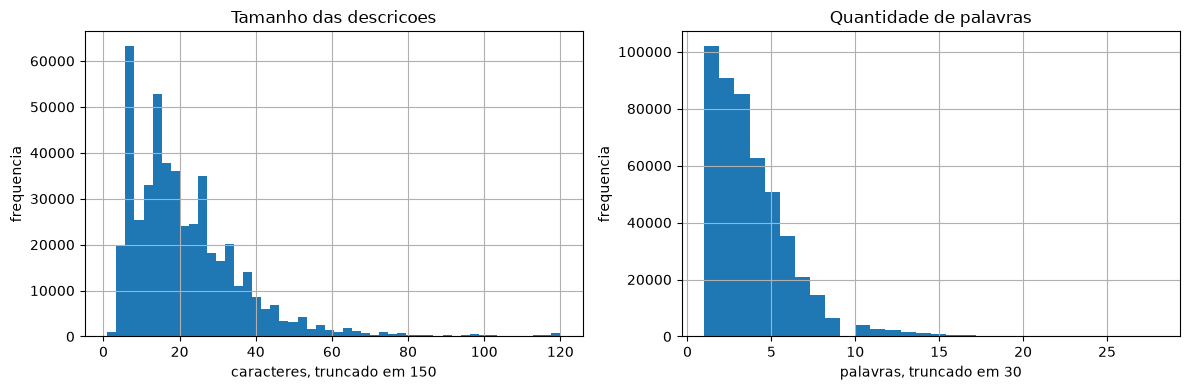

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
items["descricao_tamanho"].clip(upper=150).hist(bins=50, ax=axes[0])
axes[0].set_title("Tamanho das descricoes")
axes[0].set_xlabel("caracteres, truncado em 150")
axes[0].set_ylabel("frequencia")

items["descricao_palavras"].clip(upper=30).hist(bins=30, ax=axes[1])
axes[1].set_title("Quantidade de palavras")
axes[1].set_xlabel("palavras, truncado em 30")
axes[1].set_ylabel("frequencia")
plt.tight_layout()

In [45]:
exemplos_descricoes = pd.concat(
    [
        items.nsmallest(10, "descricao_tamanho")[[desc_col, "descricao_tamanho", "descricao_palavras", "ncm_str"]].assign(grupo="mais curtas"),
        items.nlargest(10, "descricao_tamanho")[[desc_col, "descricao_tamanho", "descricao_palavras", "ncm_str"]].assign(grupo="mais longas"),
    ],
    ignore_index=True,
)
exemplos_descricoes

,DESCRIÇÃO DO PRODUTO/SERVIÇO,descricao_tamanho,descricao_palavras,ncm_str,grupo
0,.,1,1,22011000,mais curtas
1,Pá,2,1,96039000,mais curtas
2,OVO,3,1,04072100,mais curtas
3,OVO,3,1,04071100,mais curtas
4,UVA,3,1,08061000,mais curtas
5,OVO,3,1,04072100,mais curtas
6,UVA,3,1,08061000,mais curtas
7,OVO,3,1,04071100,mais curtas
8,OVO,3,1,04071100,mais curtas
9,OVO,3,1,04071100,mais curtas


In [46]:
if UNIQUE_ITEMS_PATH.exists():
    produtos_unicos = pd.read_csv(UNIQUE_ITEMS_PATH)
    display(produtos_unicos.shape)
    display(produtos_unicos.head(20))
else:
    produtos_unicos = None
    print(f"Arquivo nao encontrado: {UNIQUE_ITEMS_PATH}")

(73786, 1)

,nome_produto
0,#1700100#17049010#TAB LC BRANCO 5
1,#1700300#18063210#TAB BT CAC 85% 5G
2,#1700300#18063210#TAB CS CAFE 5
3,"#1700700#18069000#BB PD BEIJINH 12,5"
4,"#1700700#18069000#BB PD BEM CAS 12,5"
5,"#1700700#18069000#BB PD HOLAND 12,5"
6,"#1700700#18069000#BB PD MIL FOL 11,5"
7,#1700700#18069000#CX ANG FRU SILV 75
8,#1700700#18069000#CX GOURMET 465
9,"#1700900#18069000#BB PD BRIGAD 11,5"


## 3. NCM

**Por que importa para o TCC:** permite investigar quanto conhecimento estruturado ja existe na base e se ele pode apoiar a construcao ou validacao de categorias.

In [47]:
ncm_resumo = pd.DataFrame(
    {
        "metrica": [
            "itens",
            "NCM preenchido",
            "NCM ausente",
            "NCMs unicos",
            "NCMs unicos com descricao de tipo",
        ],
        "valor": [
            len(items),
            int(items["ncm_str"].notna().sum()),
            int(items["ncm_str"].isna().sum()),
            int(items["ncm_str"].nunique()),
            int(items[ncm_tipo_col].nunique()) if ncm_tipo_col else np.nan,
        ],
    }
)
ncm_resumo

,metrica,valor
0,itens,483001
1,NCM preenchido,483001
2,NCM ausente,0
3,NCMs unicos,808
4,NCMs unicos com descricao de tipo,750


In [48]:
ncm_cols = ["ncm_str"] + ([ncm_tipo_col] if ncm_tipo_col else [])
ncm_frequentes = (
    items.groupby(ncm_cols, dropna=False)
    .agg(
        itens=(desc_col, "size"),
        descricoes_unicas=("descricao_limpa_minima", "nunique"),
        tamanho_medio_descricao=("descricao_tamanho", "mean"),
    )
    .reset_index()
    .sort_values("itens", ascending=False)
)
ncm_frequentes.head(30)

,ncm_str,NCM/SH (TIPO DE PRODUTO),itens,descricoes_unicas,tamanho_medio_descricao
236,07099990,"Outros produtos hortícolas, frescos ou refrigerados",18867,1092,13.887528
619,21069090,Outras preparações alimentícias,13200,2708,23.596439
209,07049000,"Couves, repolho, etc, do gênero Brassica, frescos ou refrigerados",12361,672,14.129925
233,07099300,"Abóboras, abobrinhas e cabaças, fresca ou refrigerada",11790,589,14.255131
228,07096000,"Pimentões e pimentas dos gêneros Capsicum ou Pimenta, frescos ou refrigerados",10192,410,17.192013
302,08039000,"Bananas frescas ou secas, exceto bananas-da-terra",9715,328,15.305713
510,19059090,"Outros produtos de padaria, pastelaria, indústria de biscoitos, etc",9228,1606,26.32694
211,07051900,Outras alfaces frescas ou refrigeradas,8234,471,13.914501
214,07061000,"Cenouras e nabos, frescos ou refrigerados",7821,324,11.236926
442,16010000,"Enchidos e produtos semelhantes, de carne, de miudezas ou de sangue; preparações alimentícias à base de tais produtos",7594,1214,22.796023


In [49]:
top_ncms_para_exemplos = ncm_frequentes.head(20)["ncm_str"].dropna().tolist()
ncm_descricoes = (
    items_for_examples[items_for_examples["ncm_str"].isin(top_ncms_para_exemplos)]
    .groupby("ncm_str", dropna=False)
    .agg(
        itens=(desc_col, "size"),
        descricoes_unicas=("descricao_limpa_minima", "nunique"),
        exemplos=(desc_col, lambda s: " | ".join(s.dropna().astype(str).drop_duplicates().head(5))),
    )
    .reset_index()
    .sort_values(["descricoes_unicas", "itens"], ascending=False)
)
ncm_descricoes

,ncm_str,itens,descricoes_unicas,exemplos
17,21069090,5540,1867,ALMOCO SUBSIDIO | Refeicao Strictu Senso | ADOCANTE SUCRALOSE ABSOLUT NUTRITION 100ML ABSOLUT | JANTAR PARCIAL | REF...
19,39241000,2361,1189,SOUSPLAT | POTE HERMETICO GRANDE 4.200 ML | COPO DESCARTAVEL 180 ML | Copo Descartavel PP Branco 200ml PCT 100UN | J...
16,19059090,3781,1017,BOLINHO INDIVIDUAL | ELMA CHIPS DORITOS Q/NACHO 140 GR | PAO DE HAMBURGUER | PAO FRANCES | Pao frances sovadinho con...
6,07099990,7935,793,HORTELA | Rúcula - Rúcula kg | AGRIAO | CHUCHU IN NATURA | COENTRO
15,16010000,3153,785,SALSICHA TIPO HOT DOG | LINGUICA TOSCANA | MORTADELA | LINGUICINHA TOSCANA CONG 1KG | SALSICHA
18,22011000,3139,731,"AGUA MINERAL 1,5 L SANTA JOANA | 20 LITROS SEM GAS - AGUA MINERAL | AGUA MIN. GARRAFAO 20L | AGUA MIN PASSA QUATRO 5..."
0,07049000,5091,476,OVO DE CODORNA | RUCULA | COUVE | REPOLHO BRANCO/VERDE | REPOLHO ROXO KG
5,07099300,4839,422,ABOBRINHA | ABOBORA | ABOBORA OU JERIMUM | MILHO VERDE | ALFACE AMERICANA
1,07051900,3415,340,Alface | BANANA PRATA | ALFACE CRESPA | ALFACE CRESPA UN VERDURA | ALFACE ROXA
7,07141000,2902,326,RAIZ DE MANDIOCA | AIPIM | MANDIOCA | MANDIOCA CONGELADA | RAÍZES DE MANDIOCA


## 4. Relacao descricao x NCM

**Por que importa para o TCC:** uma mesma descricao podendo apontar para varios NCMs, ou um NCM contendo muitas descricoes distintas, ajuda a validar a dificuldade do problema e a necessidade de tratamento textual.

Para manter o notebook reexecutavel, esta secao usa uma amostra fixa de ate 75 mil itens. As secoes anteriores ja trazem contagens globais de linhas, descricoes e NCMs.

In [50]:
descricao_para_ncm = (
    items_for_relation.groupby("descricao_limpa_minima")
    .agg(
        ocorrencias=(desc_col, "size"),
        ncms_unicos=("ncm_str", "nunique"),
        exemplo_original=(desc_col, "first"),
    )
    .reset_index()
    .sort_values(["ncms_unicos", "ocorrencias"], ascending=False)
)
top_descricoes_ncm = descricao_para_ncm.head(30).merge(
    items_for_relation.groupby("descricao_limpa_minima")["ncm_str"]
    .apply(lambda s: ", ".join(s.dropna().drop_duplicates().head(10)))
    .rename("exemplos_ncm")
    .reset_index(),
    on="descricao_limpa_minima",
    how="left",
)
top_descricoes_ncm

,descricao_limpa_minima,ocorrencias,ncms_unicos,exemplo_original,exemplos_ncm
0,batata doce,555,32,BATATA DOCE,"07142000, 20052000, 07049000, 07011000, 07149000, 07101000, 20079910, 08109012, 08134090, 07099300"
1,coentro,294,30,COENTRO,"07052900, 09096190, 07039090, 07099990, 07099300, 09092100, 07089000, 09109900, 07031019, 07049000"
2,cenoura,816,22,CENOURA,"07061000, 07069000, 21069090, 08081000, 07089000, 07031019, 07099990, 07099300, 07108000, 07011000"
3,cebolinha,371,22,CEBOLINHA,"07039090, 07031019, 07070000, 07108000, 07032090, 07089000, 07099990, 21039029, 09109900, 07051100"
4,maracuja,123,21,MARACUJA,"08093020, 07070000, 08109015, 20098913, 08134090, 07099990, 08025100, 08059000, 08045030, 08109090"
5,abobora,397,20,ABOBORA,"07099300, 07099990, 07095900, 08031000, 07069000, 20089900, 07143000, 07141000, 25010020, 21069090"
6,cheiro verde,205,20,CHEIRO VERDE,"07099990, 07141000, 07041000, 21039029, 09109900, 07049000, 07051900, 07039090, 07099300, 07089000"
7,melancia,629,19,MELANCIA,"08071100, 07099990, 08071900, 07070000, 08109090, 08109012, 07099300, 08081000, 03039200, 08043000"
8,banana prata,523,19,BANANA PRATA,"08039000, 08031000, 20079990, 20079923, 09011110, 19059090, 08071900, 08071100, 08119000, 07051900"
9,salsa,169,19,Salsa,"07031019, 07099990, 07039090, 09011110, 07052900, 07133399, 07031029, 07049000, 07019000, 07069000"


In [51]:
descricoes_com_varios_ncms = descricao_para_ncm[descricao_para_ncm["ncms_unicos"] > 1]
pd.DataFrame(
    {
        "metrica": [
            "descricoes com mais de um NCM na amostra",
            "percentual das descricoes unicas na amostra",
            "ocorrencias afetadas na amostra",
            "percentual dos itens da amostra",
        ],
        "valor": [
            len(descricoes_com_varios_ncms),
            f"{len(descricoes_com_varios_ncms) / len(descricao_para_ncm):.2%}",
            int(descricoes_com_varios_ncms["ocorrencias"].sum()),
            f"{descricoes_com_varios_ncms['ocorrencias'].sum() / len(items_for_relation):.2%}",
        ],
    }
)

,metrica,valor
0,descricoes com mais de um NCM na amostra,1449
1,percentual das descricoes unicas na amostra,6.06%
2,ocorrencias afetadas na amostra,31786
3,percentual dos itens da amostra,42.38%


In [52]:
if not descricoes_com_varios_ncms.empty:
    exemplo_desc = descricoes_com_varios_ncms.iloc[0]["exemplo_original"]
    display(items_for_relation[items_for_relation[desc_col].astype("string").str.strip().str.lower() == str(exemplo_desc).strip().lower()][
        [col for col in [desc_col, "ncm_str", ncm_tipo_col, emitente_col, uf_col, municipio_col] if col]
    ].drop_duplicates().head(30))
else:
    print("Nao foram encontradas descricoes associadas a mais de um NCM.")

,DESCRIÇÃO DO PRODUTO/SERVIÇO,ncm_str,NCM/SH (TIPO DE PRODUTO),RAZÃO SOCIAL EMITENTE,UF EMITENTE,MUNICÍPIO EMITENTE
23886,BATATA DOCE,07142000,"Batatas-doces, frescas, refrigeradas, congeladas ou secas",MERCADO BELLINI LTDA,MG,JUIZ DE FORA
421703,BATATA DOCE,07142000,"Batatas-doces, frescas, refrigeradas, congeladas ou secas",ASSOCIACAO DOS PRODUTORES RURAIS DO MUNICIPIO DE PICOS E CID,PI,PICOS
127272,Batata doce,20052000,"Batatas, preparados ou conservados, exceto em vinagre ou em ácido acético, não congelados",ASSOC. DOS AGRICUTORES FAMILIARES DO MUN. CASCAVEL,PR,CASCAVEL
417798,BATATA DOCE,07142000,"Batatas-doces, frescas, refrigeradas, congeladas ou secas",INSTITUTO DE ASSISTÊNCIA TÉCNICA E EXTENSÃO RURAL DO RIO,RN,NATAL
407005,BATATA DOCE,07142000,"Batatas-doces, frescas, refrigeradas, congeladas ou secas",ROSANGELA RAMOS MENDES,RJ,PATY DO ALFERES
471095,BATATA DOCE,07142000,"Batatas-doces, frescas, refrigeradas, congeladas ou secas",REFISERVI REFEICOES INDUSTRIAIS LTDA,RJ,RIO DE JANEIRO
127090,BATATA DOCE,07142000,"Batatas-doces, frescas, refrigeradas, congeladas ou secas",N S APARECIDA DISTRIBUIDORA DE ALIMENTOS E TRANSPORTE LTDA,RJ,DUQUE DE CAXIAS
221320,BATATA DOCE,07142000,"Batatas-doces, frescas, refrigeradas, congeladas ou secas",COOP DE AGRICULTORES E AGRO FAMILIARES E CAXIAS DO SUL LTDA,RS,CAXIAS DO SUL
168547,BATATA DOCE,07142000,"Batatas-doces, frescas, refrigeradas, congeladas ou secas",J F DA SILVA HORTIFRUTI LTDA,PR,ASTORGA
7529,BATATA DOCE,07142000,"Batatas-doces, frescas, refrigeradas, congeladas ou secas",COOPERATIVA DE AGRICULTURA DO ESTADO DO RS,RS,SANTA ROSA


In [53]:
top_ncms_heterogeneos = (
    items.groupby("ncm_str", dropna=False)
    .agg(ocorrencias=(desc_col, "size"), descricoes_unicas=("descricao_limpa_minima", "nunique"))
    .reset_index()
    .sort_values(["descricoes_unicas", "ocorrencias"], ascending=False)
    .head(30)
)
exemplos_por_ncm = (
    items_for_examples[items_for_examples["ncm_str"].isin(top_ncms_heterogeneos["ncm_str"].dropna())]
    .groupby("ncm_str", dropna=False)[desc_col]
    .apply(lambda s: " | ".join(s.dropna().astype(str).drop_duplicates().head(8)))
    .rename("exemplos_descricao")
    .reset_index()
)
ncm_para_descricao = top_ncms_heterogeneos.merge(exemplos_por_ncm, on="ncm_str", how="left")
ncm_para_descricao

,ncm_str,ocorrencias,descricoes_unicas,exemplos_descricao
0,21069090,13200,2708,ALMOCO SUBSIDIO | Refeicao Strictu Senso | ADOCANTE SUCRALOSE ABSOLUT NUTRITION 100ML ABSOLUT | JANTAR PARCIAL | REF...
1,39241000,5921,2407,SOUSPLAT | POTE HERMETICO GRANDE 4.200 ML | COPO DESCARTAVEL 180 ML | Copo Descartavel PP Branco 200ml PCT 100UN | J...
2,19059090,9228,1606,BOLINHO INDIVIDUAL | ELMA CHIPS DORITOS Q/NACHO 140 GR | PAO DE HAMBURGUER | PAO FRANCES | Pao frances sovadinho con...
3,39249000,3065,1425,"PA DE LIXO COM CABO FECHADA | CAIXA PLASTICA, MATERIAL PLASTICO, COMPRIMENTO 335MM, LARGURA 240MM, ALTURA 160MM, CAR..."
4,22021000,5263,1404,REFRIGERANTE SABOR COLA 2 LT | SUCO LIQUIDO LARANJA 200 ML | CAJUÍNA(CLASSIFICAÇÃO SEM CARACTERÍSTICAS) | REFRIGERAN...
5,19053100,4493,1393,PAO DE QUEIJO | BISCOITO WAFER SABOR CHOCOLATE PACOTE DE 140G | BISCOITO SALGADO | BISCOITO CREAM CRACKER | BISCOITO...
6,34025000,4566,1349,DESENG.ZAP CLEAN LIMAO REFIL | DETERGENTE LIQUIDO 500 ML NEUTRO | Luva verde (G) | VEJA MULTIUSO LAV.ALC.500ML | LIM...
7,96039000,4499,1268,RODO 40CM | RODO | RODO 60CM C/CABO MADEIRA | Apagador de Quadro Pilot 150N Flip Top Branco | ESCOVA DE VASO SANITAR...
8,16010000,7594,1214,SALSICHA TIPO HOT DOG | LINGUICA TOSCANA | MORTADELA | LINGUICINHA TOSCANA CONG 1KG | SALSICHA | LINGUICA TOSCANA FR...
9,22011000,7575,1107,"AGUA MINERAL 1,5 L SANTA JOANA | 20 LITROS SEM GAS - AGUA MINERAL | AGUA MIN. GARRAFAO 20L | AGUA MIN PASSA QUATRO 5..."


## 5. Contexto da compra

**Por que importa para o TCC:** emitentes, localidades, unidades, quantidades e valores ajudam a compreender de onde vem a heterogeneidade textual da base.

In [54]:
contexto_resumo = pd.DataFrame(
    {
        "campo": ["emitentes", "UFs", "municipios", "unidades"],
        "unicos": [
            items[emitente_col].nunique() if emitente_col else np.nan,
            items[uf_col].nunique() if uf_col else np.nan,
            items[municipio_col].nunique() if municipio_col else np.nan,
            items[unidade_col].nunique() if unidade_col else np.nan,
        ],
        "preenchimento_pct": [
            round(100 * items[emitente_col].notna().mean(), 2) if emitente_col else np.nan,
            round(100 * items[uf_col].notna().mean(), 2) if uf_col else np.nan,
            round(100 * items[municipio_col].notna().mean(), 2) if municipio_col else np.nan,
            round(100 * items[unidade_col].notna().mean(), 2) if unidade_col else np.nan,
        ],
    }
)
contexto_resumo

,campo,unicos,preenchimento_pct
0,emitentes,18951,100.00
1,UFs,27,100.00
2,municipios,2327,100.00
3,unidades,682,99.97


In [55]:
def top_counts(column, n=20):
    """Return top frequencies for a categorical column."""
    return (
        items[column]
        .astype("string")
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="itens")
        .assign(percentual=lambda d: pct(d["itens"] / len(items)))
        .head(n)
    )

if emitente_col:
    display(top_counts(emitente_col, 20))
if uf_col:
    display(top_counts(uf_col, 20))
if municipio_col:
    display(top_counts(municipio_col, 20))
if unidade_col:
    display(top_counts(unidade_col, 30))

,RAZÃO SOCIAL EMITENTE,itens,percentual
0,BRS SUPRIMENTOS CORPORATIVOS S/A,12713,2.63
1,REFISERVI REFEICOES INDUSTRIAIS LTDA,9653,2.0
2,CARREFOUR COMERCIO E INDUSTRIA LTDA,6276,1.3
3,FIEIS DA TERRA ATACADISTA LTDA,6139,1.27
4,COMSABOR COMERCIO DE ALIMENTOS LTDA - ME,5363,1.11
5,N S APARECIDA DISTRIBUIDORA DE ALIMENTOS E TRANSPORTE LTDA,4798,0.99
6,SOLL -SERVICOS OBRAS E LOCACOES LTDA,4513,0.93
7,NARA COMERCIAL DE ALIMENTOS LTDA ME,4409,0.91
8,J E S COML. DE ALIM. LTDA,3184,0.66
9,COMPANHIA NACIONAL DE ABASTECIMENTO,3144,0.65


,UF EMITENTE,itens,percentual
0,RJ,76408,15.82
1,RS,50245,10.4
2,SP,36998,7.66
3,MG,30960,6.41
4,PR,29701,6.15
5,DF,28144,5.83
6,PA,26726,5.53
7,PE,24864,5.15
8,AM,23565,4.88
9,BA,20238,4.19


,MUNICÍPIO EMITENTE,itens,percentual
0,RIO DE JANEIRO,50704,10.5
1,BRASILIA,25317,5.24
2,MANAUS,18232,3.77
3,SAO PAULO,11306,2.34
4,NATAL,9592,1.99
5,SAO LEOPOLDO,8596,1.78
6,TERESINA,8026,1.66
7,PATO BRANCO,7656,1.59
8,JUIZ DE FORA,6509,1.35
9,CAMPO GRANDE,6488,1.34


,UNIDADE,itens,percentual
0,KG,252901,52.36
1,UNIDAD,141587,29.31
2,PCT,9429,1.95
3,PEÇA,6494,1.34
4,CX,5467,1.13
5,KG0001,5422,1.12
6,PAC,4283,0.89
7,LITRO,3497,0.72
8,UN1,3250,0.67
9,KG1,2824,0.58


In [56]:
numeric_cols = [col for col in ["quantidade_num", "valor_unitario_num", "valor_total_num", "valor_nota_num"] if col in items.columns]
items[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,quantidade_num,valor_unitario_num,valor_total_num,valor_nota_num
count,483001.0,483001.0,483001.0,0.0
mean,266.509475,39.030011,2002.644234,<NA>
std,6359.511798,2927.737168,29135.032703,<NA>
min,0.0,0.0,0.0,<NA>
1%,0.7,0.81,2.6,<NA>
5%,1.0,1.69,9.75,<NA>
25%,8.0,4.0,59.4,<NA>
50%,25.0,7.0,187.5,<NA>
75%,80.0,14.0,624.1,<NA>
95%,550.0,45.04,4140.0,<NA>


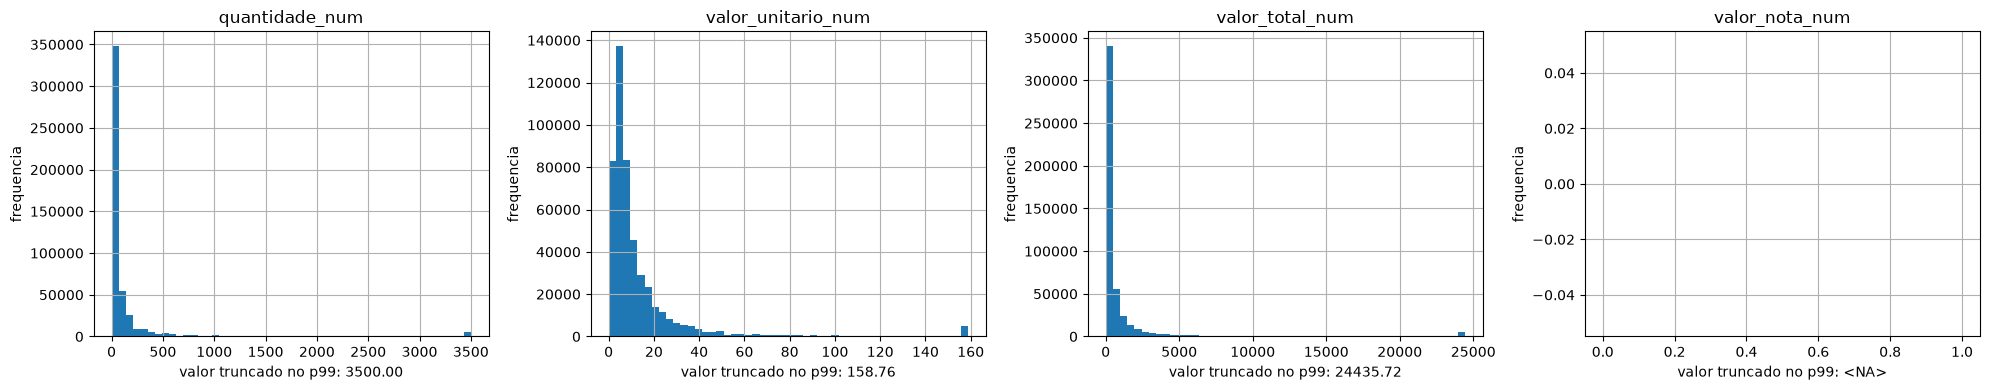

In [57]:
if numeric_cols:
    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
    if len(numeric_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_cols):
        upper = items[col].quantile(0.99)
        items[col].clip(upper=upper).hist(bins=50, ax=ax)
        ax.set_title(col)
        ax.set_xlabel(f"valor truncado no p99: {upper:.2f}")
        ax.set_ylabel("frequencia")
    plt.tight_layout()
else:
    print("Nenhuma coluna numerica de contexto foi detectada.")

In [58]:
agrupadores_contexto = [col for col in [uf_col, municipio_col, emitente_col, unidade_col] if col]
for col in agrupadores_contexto:
    resumo = (
        items.groupby(col, dropna=False)
        .agg(
            itens=(desc_col, "size"),
            descricoes_unicas=("descricao_limpa_minima", "nunique"),
            ncms_unicos=("ncm_str", "nunique"),
            tamanho_medio_descricao=("descricao_tamanho", "mean"),
        )
        .assign(descricoes_por_100_itens=lambda d: 100 * d["descricoes_unicas"] / d["itens"])
        .sort_values("itens", ascending=False)
        .head(20)
    )
    print(f"\nResumo por {col}")
    display(resumo)


Resumo por UF EMITENTE


,itens,descricoes_unicas,ncms_unicos,tamanho_medio_descricao,descricoes_por_100_itens
UF EMITENTE,,,,,
RJ,76408,10799,512,18.773715,14.133337
RS,50245,7442,443,25.801572,14.811424
SP,36998,6989,473,24.892535,18.890210
MG,30960,6526,472,22.062468,21.078811
PR,29701,5485,439,23.040908,18.467392
DF,28144,4680,442,22.047435,16.628766
PA,26726,4192,435,22.49304,15.685101
PE,24864,3575,417,21.092986,14.378218
AM,23565,3835,422,22.777254,16.274135



Resumo por MUNICÍPIO EMITENTE


,itens,descricoes_unicas,ncms_unicos,tamanho_medio_descricao,descricoes_por_100_itens
MUNICÍPIO EMITENTE,,,,,
RIO DE JANEIRO,50704,7066,464,18.358808,13.935784
BRASILIA,25317,4247,434,21.929534,16.775289
MANAUS,18232,2927,382,24.537407,16.054190
SAO PAULO,11306,2026,297,23.087653,17.919689
NATAL,9592,1788,316,21.349875,18.640534
SAO LEOPOLDO,8596,312,52,40.996277,3.629595
TERESINA,8026,1458,278,23.667331,18.165961
PATO BRANCO,7656,942,165,21.382445,12.304075
JUIZ DE FORA,6509,819,226,14.069135,12.582578



Resumo por RAZÃO SOCIAL EMITENTE


,itens,descricoes_unicas,ncms_unicos,tamanho_medio_descricao,descricoes_por_100_itens
RAZÃO SOCIAL EMITENTE,,,,,
BRS SUPRIMENTOS CORPORATIVOS S/A,12713,418,60,40.983324,3.287973
REFISERVI REFEICOES INDUSTRIAIS LTDA,9653,122,38,7.289547,1.263856
CARREFOUR COMERCIO E INDUSTRIA LTDA,6276,468,134,21.869503,7.456979
FIEIS DA TERRA ATACADISTA LTDA,6139,47,31,6.92963,0.765597
COMSABOR COMERCIO DE ALIMENTOS LTDA - ME,5363,606,109,21.140779,11.299646
N S APARECIDA DISTRIBUIDORA DE ALIMENTOS E TRANSPORTE LTDA,4798,59,37,11.636307,1.229679
SOLL -SERVICOS OBRAS E LOCACOES LTDA,4513,70,20,25.955019,1.551075
NARA COMERCIAL DE ALIMENTOS LTDA ME,4409,705,164,19.705375,15.990020
J E S COML. DE ALIM. LTDA,3184,143,43,23.851445,4.491206



Resumo por UNIDADE


,itens,descricoes_unicas,ncms_unicos,tamanho_medio_descricao,descricoes_por_100_itens
UNIDADE,,,,,
KG,252901,16714,623,16.84388,6.608910
UNIDAD,141587,37089,637,28.01063,26.195202
PCT,9429,2467,265,27.156963,26.163962
PEÇA,6494,2578,255,29.519403,39.698183
CX,5467,1604,249,32.329797,29.339674
KG0001,5422,235,79,21.420693,4.334194
PAC,4283,102,36,39.193556,2.381508
LITRO,3497,847,167,28.068058,24.220761
UN1,3250,2021,274,27.878462,62.184615


## Fechamento

Pontos para levar para a escrita do TCC:

- tamanho e cobertura da base antes do preprocessamento;
- evidencia empirica de textos curtos e ruidosos;
- disponibilidade e concentracao dos NCMs;
- casos em que descricao e NCM nao formam uma relacao simples de um-para-um;
- heterogeneidade causada por emitentes, localidades, unidades e padroes de valor.